In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']   #显示中文
plt.rcParams['axes.unicode_minus']=False       #显示负号
# plt.rcParams['font.family'] = 'Times New Roman'
from keras import  Model
from keras.optimizers import Adam
from keras.layers import Input, Layer,Dense, ReLU,Reshape,Flatten
import tensorflow as tf
from utils import plot_real_vs_pred,BinsrPlot,ErrorPlot

In [13]:
def compute_degree_matrix(A):
    """
    A:自带自环的矩阵
    """
    s = np.sum(A, axis=1)
    s = np.sqrt(s)
    s = 1/s
    D = np.diag(s)
    D = D.astype(np.float32)
    return np.sqrt(D)

In [14]:
data = np.load("data.npz",allow_pickle=True)
adj = data['adj']
X_train, X_test, y_train = data['X_train'], data['X_test'], data['y_train']

In [15]:
print(adj)

[[1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]]


In [16]:

dim = X_train.shape[-1]
Node = adj.shape[0]
seq_len = X_train.shape[1]

In [17]:
A = compute_degree_matrix(adj)

In [18]:
class GCN(Layer):
    def __init__(self, units,name=None):
        super(GCN, self).__init__(name=name)
        self.units = units
        
    def build(self, input_shape):
        self.kernel = Dense(self.units)
        self.relu = ReLU()

    def call(self, inputs,A):
        """
        A:NxN,矩阵A+I的倒数的开平方
        Fea:NxD
        """
        Fea = self.kernel(inputs)
        Fea = self.relu(Fea)
        mat_left = tf.matmul(A, Fea)
        mat_left = tf.transpose(mat_left, [0,1, 3, 2])
        mat_right = tf.matmul(mat_left,A)
        mat_right = tf.transpose(mat_right, [0,1, 3, 2])
        return mat_right


In [19]:
from CustomLayers0 import Encoder

In [20]:
inp = Input((seq_len,Node,dim))
g1 = GCN(32)(inp,A)
g2 = GCN(32)(g1,A)
st = Reshape((seq_len,-1))(g2)
st = Dense(64, activation='relu')(st)
o1 = Encoder(64, 2, seq_len, 0.1, 2)(st)
o1 = Flatten()(o1)
out = Dense(1)(o1)
model = Model(inputs=inp, outputs=out)
model.compile(optimizer=Adam(0.001), loss="mae", metrics=["mae"])

In [21]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2, 9, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_2 (GCN)                     │ (None, 2, 9, 32)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_3 (GCN)                     │ (None, 2, 9, 32)       │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 2, 288)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2, 64)          │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Encoder)             │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,745 (77.13 KB)

 Trainable params: 19,745 (77.13 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
 # 划分训练集和验证集
X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

In [23]:

import time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

# 假设 X_train 和 y_train 已经是 NumPy 数组，seq_len, Node, dim 也已经定义

# 存储每一折的结果
rmse_scores = []
mae_scores = []
mape_scores = []
r2_scores = []

# 存储每轮的训练时间
fold_times = []

# 存储每一轮的训练时间（每一折的时间）
epoch_times = []

# 初始化五折交叉验证
kf = KFold(n_splits=5, shuffle=True, random_state=42)


# 记录总的开始时间
total_start_time = time.time()

# 五折交叉验证训练过程
for fold, (train_index, val_index) in enumerate(kf.split(X_train), 1):
    # 记录每一折开始的时间
    fold_start_time = time.time()
    # 训练模型
    history = model.fit(
        X_train_fold,
        y_train_fold,
        epochs=500,
        batch_size=32,
        shuffle=False,
        verbose=2,
        validation_data=(X_val_fold, y_val_fold))
    # 划分训练集和验证集
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    

    # 每一折的训练过程
    fold_epoch_time = 0  # 每一折的训练时间
    for epoch in range(120):
        epoch_start_time = time.time()  # 记录每一轮的开始时间
        
      
        
        # 计算每一轮的时间
        epoch_end_time = time.time()
        epoch_time = epoch_end_time - epoch_start_time
        fold_epoch_time += epoch_time
        epoch_times.append(epoch_time)
        print(f"Fold {fold} - Epoch {epoch + 1} training time: {epoch_time:.2f} seconds")

    # 记录每一折的训练时间
    fold_end_time = time.time()
    fold_time = fold_end_time - fold_start_time
    fold_times.append(fold_time)
    print(f"Fold {fold} total training time: {fold_time:.2f} seconds")
    
    # 计算RMSE, MAE, MAPE, R2在验证集上的值
    y_val_pred = model.predict(X_val_fold)

    # 计算RMSE
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))
    rmse_scores.append(rmse)

    # 计算MAE
    mae = mean_absolute_error(y_val_fold, y_val_pred)
    mae_scores.append(mae)

    # 计算MAPE
    mape = np.mean(np.abs((y_val_fold - y_val_pred) / y_val_fold)) * 100
    mape_scores.append(mape)

    # 计算R2
    r2 = r2_score(y_val_fold, y_val_pred)
    r2_scores.append(r2)

# 计算总的训练时间
total_end_time = time.time()
total_time = total_end_time - total_start_time

# 计算每轮的平均训练时间
average_epoch_time = total_time / 5  # 5 folds

# 计算每轮的总时间
average_fold_time = np.mean(fold_times)

# 计算均值和标准差
rmse_mean = np.mean(rmse_scores)
rmse_std = np.std(rmse_scores)

mae_mean = np.mean(mae_scores)
mae_std = np.std(mae_scores)

mape_mean = np.mean(mape_scores)
mape_std = np.std(mape_scores)

r2_mean = np.mean(r2_scores)  # 计算 R2 的均值
r2_std = np.std(r2_scores)    # 计算 R2 的标准差

# 输出最终结果
print(f"\nRMSE Mean: {rmse_mean}, RMSE Std: {rmse_std}")
print(f"MAE Mean: {mae_mean}, MAE Std: {mae_std}")
print(f"MAPE Mean: {mape_mean}, MAPE Std: {mape_std}")
print(f"R2 Mean: {r2_mean}, R2 Std: {r2_std}")

# 输出总的训练时间和每轮的平均时间
print(f"Total training time: {total_time:.2f} seconds")
print(f"Average training time per fold: {average_fold_time:.2f} seconds")
print(f"Average training time per epoch: {average_epoch_time:.2f} seconds")

# 保存结果到CSV
results_df = pd.DataFrame({
    'Fold': [i+1 for i in range(5)],
    'RMSE': rmse_scores,
    'MAE': mae_scores,
    'MAPE': mape_scores,
    'R2': r2_scores,
    'Fold Time': fold_times,  # 每个fold总时间
})

# 计算平均值和标准差
results_df.loc['Mean'] = [None, rmse_mean, mae_mean, mape_mean, r2_mean, average_fold_time]
results_df.loc['Std'] = [None, rmse_std, mae_std, mape_std, r2_std, None]




Epoch 1/500


16/16 - 5s - 321ms/step - loss: 0.7147 - mae: 0.7147 - val_loss: 0.3830 - val_mae: 0.3830
Epoch 2/500
16/16 - 0s - 11ms/step - loss: 0.4600 - mae: 0.4600 - val_loss: 0.2924 - val_mae: 0.2924
Epoch 3/500
16/16 - 0s - 11ms/step - loss: 0.3855 - mae: 0.3855 - val_loss: 0.2977 - val_mae: 0.2977
Epoch 4/500
16/16 - 0s - 11ms/step - loss: 0.3583 - mae: 0.3583 - val_loss: 0.3048 - val_mae: 0.3048
Epoch 5/500
16/16 - 0s - 11ms/step - loss: 0.3326 - mae: 0.3326 - val_loss: 0.2726 - val_mae: 0.2726
Epoch 6/500
16/16 - 0s - 11ms/step - loss: 0.3180 - mae: 0.3180 - val_loss: 0.2687 - val_mae: 0.2687
Epoch 7/500
16/16 - 0s - 11ms/step - loss: 0.3124 - mae: 0.3124 - val_loss: 0.2672 - val_mae: 0.2672
Epoch 8/500
16/16 - 0s - 11ms/step - loss: 0.3087 - mae: 0.3087 - val_loss: 0.2639 - val_mae: 0.2639
Epoch 9/500
16/16 - 0s - 11ms/step - loss: 0.3003 - mae: 0.3003 - val_loss: 0.2659 - val_mae: 0.2659
Epoch 10/500
16/16 - 0s - 11ms/step - loss: 0.3115 - mae: 0.3115 - val_loss: 0.2773 - val_mae: 0.2773


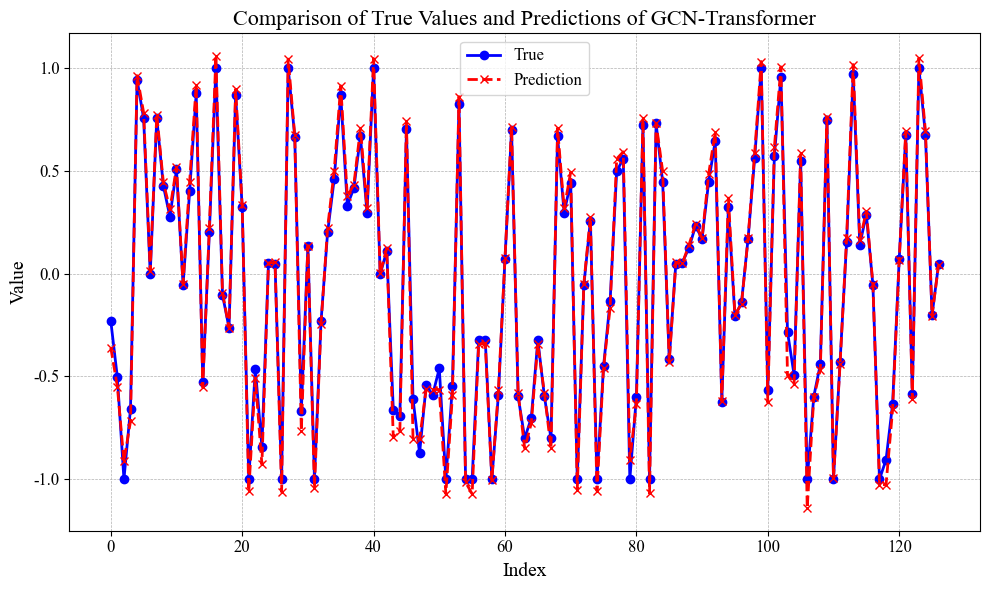

In [24]:
import matplotlib.pyplot as plt

# 假设 REALS 和 PREDS 是两个相同长度的列表或数组
# 如果它们还没有定义，请确保在调用 plot 之前定义它们

# 创建一个新的图形
plt.figure(figsize=(10, 6))  # 设置图形大小

# 绘制真实值
plt.plot(y_val_fold, label='True', color='blue', marker='o', linestyle='-', linewidth=2)

# 绘制预测值
plt.plot( y_val_pred, label='Prediction', color='red', marker='x', linestyle='--', linewidth=2)

# 添加标题和坐标轴标签
plt.title('Comparison of True Values and Predictions of GCN-Transformer', fontsize=16)
plt.xlabel('Index', fontsize=14)  # X 轴标签
plt.ylabel('Value', fontsize=14)  # Y 轴标签

# 显示图例
plt.legend(fontsize=12)

# 添加网格线
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 确保 x 轴和 y 轴的刻度标签足够大，以便阅读
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 自动调整布局以适应图形窗口
plt.tight_layout()
plt.savefig('C:\\Users\\Administrator\\Desktop\\kan最新结果\\gat\\Comparison of True Values and Predictions of GCN-Transformer', dpi=900, bbox_inches='tight')

# 显示图形
plt.show()

In [25]:
# 保存到CSV
results_df.to_csv('GCNTransformercross_validation_results.csv', index=True)

print("Results saved to 'cross_validation_results.csv'.")

Results saved to 'cross_validation_results.csv'.


In [26]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import tensorflow as tf

# 假设 X_train 和 y_train 已经是 NumPy 数组，seq_len, Node, dim 也已经定义

# 存储每一折的结果
rmse_scores = []
mae_scores = []
mape_scores = []
r2_scores = []

# 初始化五折交叉验证
kf = KFold(n_splits=5, shuffle=True, random_state=42)


# 五折交叉验证训练过程
for train_index, val_index in kf.split(X_train):
    # 划分训练集和验证集
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]



    # 训练模型
    history = model.fit(
        X_train_fold,
        y_train_fold,
        epochs=120,
        batch_size=32,
        shuffle=False,
        verbose=2,
        validation_data=(X_val_fold, y_val_fold)
    )
    
    # 计算RMSE, MAE, MAPE, R2在验证集上的值
    y_val_pred = model.predict(X_val_fold)

    # 计算RMSE
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))
    rmse_scores.append(rmse)

    # 计算MAE
    mae = mean_absolute_error(y_val_fold, y_val_pred)
    mae_scores.append(mae)

    # 计算MAPE
    mape = np.mean(np.abs((y_val_fold - y_val_pred) / y_val_fold)) * 100
    mape_scores.append(mape)

    # 计算R2
    r2 = r2_score(y_val_fold, y_val_pred)
    r2_scores.append(r2)

# 计算均值和标准差
rmse_mean = np.mean(rmse_scores)
rmse_std = np.std(rmse_scores)

mae_mean = np.mean(mae_scores)
mae_std = np.std(mae_scores)

mape_mean = np.mean(mape_scores)
mape_std = np.std(mape_scores)

r2_mean = np.mean(r2_scores)  # 计算 R2 的均值
r2_std = np.std(r2_scores)    # 计算 R2 的标准差

# 输出最终结果
print(f"\nRMSE Mean: {rmse_mean}, RMSE Std: {rmse_std}")
print(f"MAE Mean: {mae_mean}, MAE Std: {mae_std}")
print(f"MAPE Mean: {mape_mean}, MAPE Std: {mape_std}")
print(f"R2 Mean: {r2_mean}, R2 Std: {r2_std}")


Epoch 1/120
16/16 - 0s - 12ms/step - loss: 0.0477 - mae: 0.0477 - val_loss: 0.0361 - val_mae: 0.0361
Epoch 2/120
16/16 - 0s - 10ms/step - loss: 0.0425 - mae: 0.0425 - val_loss: 0.0327 - val_mae: 0.0327
Epoch 3/120
16/16 - 0s - 10ms/step - loss: 0.0426 - mae: 0.0426 - val_loss: 0.0286 - val_mae: 0.0286
Epoch 4/120
16/16 - 0s - 11ms/step - loss: 0.0422 - mae: 0.0422 - val_loss: 0.0289 - val_mae: 0.0289
Epoch 5/120
16/16 - 0s - 11ms/step - loss: 0.0437 - mae: 0.0437 - val_loss: 0.0472 - val_mae: 0.0472
Epoch 6/120
16/16 - 0s - 10ms/step - loss: 0.0451 - mae: 0.0451 - val_loss: 0.0493 - val_mae: 0.0493
Epoch 7/120
16/16 - 0s - 10ms/step - loss: 0.0424 - mae: 0.0424 - val_loss: 0.0464 - val_mae: 0.0464
Epoch 8/120
16/16 - 0s - 10ms/step - loss: 0.0421 - mae: 0.0421 - val_loss: 0.0350 - val_mae: 0.0350
Epoch 9/120
16/16 - 0s - 10ms/step - loss: 0.0422 - mae: 0.0422 - val_loss: 0.0333 - val_mae: 0.0333
Epoch 10/120
16/16 - 0s - 10ms/step - loss: 0.0417 - mae: 0.0417 - val_loss: 0.0343 - val_m

KeyboardInterrupt: 

In [11]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# 使用模型在训练集上进行预测
y_pred = model.predict(X_train)

# 计算 MAE (Mean Absolute Error)
mae = mean_absolute_error(y_train, y_pred)

# 计算 MSE (Mean Squared Error)
mse = mean_squared_error(y_train, y_pred)

# 计算 RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)

# 计算 R² (R-squared)
r2 = r2_score(y_train, y_pred)

# 打印所有指标
print(f'MAE: {mae:.4f}')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R²: {r2:.4f}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
MAE: 0.1174
MSE: 0.0317
RMSE: 0.1780
R²: 0.9298


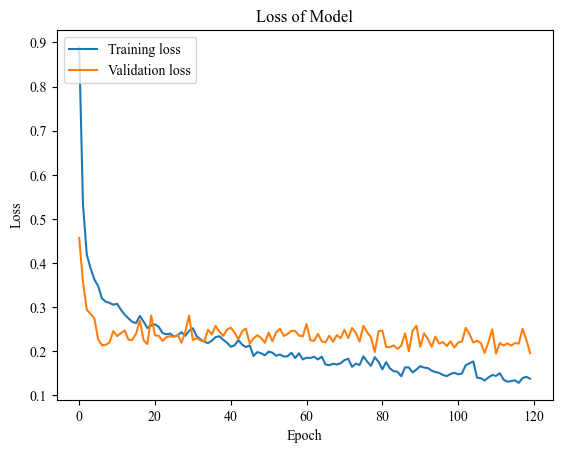

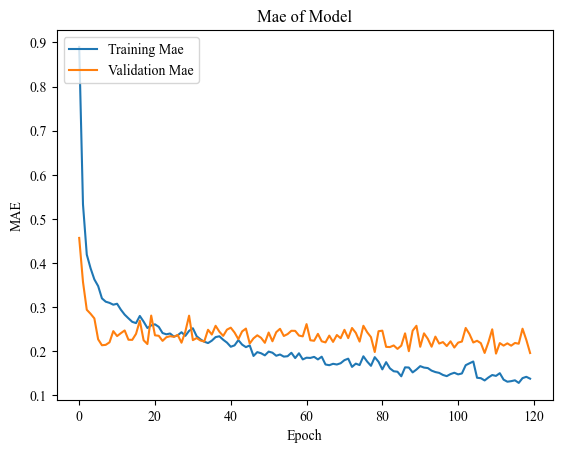

In [12]:

# 绘制训练损失和验证损失
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss of Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training loss', 'Validation loss'], loc='upper left')
plt.show()

plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Mae of Model')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Training Mae', 'Validation Mae'], loc='upper left')
plt.show()

In [13]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [14]:
X_test = X_test.tolist()

In [15]:
results = {}
all_test = []
all_preds = []

def inverse_transform(scaler_max,scaler_min,y_pred):
    return y_pred*(scaler_max-scaler_min)+scaler_min


for k in X_test.keys():
    x_in = X_test[k]['x']
    y_test = X_test[k]['y']
    scaler_data_max_ = X_test[k]['scaler_max'][-1]
    scaler_data_min_ = X_test[k]['scaler_min'][-1]
    y_pred = model(np.expand_dims(x_in,axis=-1)).numpy()
    y_pred = inverse_transform(scaler_max=scaler_data_max_,scaler_min=scaler_data_min_,y_pred=y_pred)
    y_test = inverse_transform(scaler_max=scaler_data_max_,scaler_min=scaler_data_min_,y_pred=y_test)
    results[k] = {'y_pred':y_pred,'y_test':y_test}
    all_test.append(y_test)
    all_preds.append(y_pred)
all_test = np.concatenate(all_test,axis=0)
all_preds = np.concatenate(all_preds,axis=0)

In [16]:
print('mae:',mean_absolute_error(all_test,all_preds))
print('mse:',mean_squared_error(all_test,all_preds))
print('rmse:',np.sqrt(mean_squared_error(all_test,all_preds)))
print('r2:',r2_score(all_test,all_preds))

mae: 0.31907800738464215
mse: 0.19166102203356455
rmse: 0.4377910712127014
r2: 0.868554451938438


In [17]:
PREDS = []
REALS = []
for k in results:
    plt.figure(figsize=(6,3))
    y_Pred = results[k]['y_pred'].squeeze()
    y_True = results[k]['y_test'].squeeze()

    PREDS.extend(y_Pred)
    REALS.extend(y_True)
    fig, ax = plt.subplots(figsize=(10, 3))  # 设置图形尺寸

    # 绘制预测和真实值曲线，并指定颜色和线型
    ax.plot(y_Pred, 'b-', label='Prediction', lw=2)  # 预测值用蓝色实线
    ax.plot(y_True, 'r--', label='True Value', lw=2)  # 真实值用红色虚线

    # 设置横轴为整数，并根据数据长度适当调整刻度间隔
    tick_interval = 1 if len(y_Pred) <= 20 else len(y_Pred) // 10  # 如果数据点少于20个，则每个都显示；否则每隔10个显示一次
    ax.set_xticks(range(0, len(y_Pred), tick_interval))

    # 设置坐标轴标签
    ax.set_xlabel('Time (Year)', fontsize=12)
    ax.set_ylabel('TFPLP', fontsize=12)

    # 添加网格
    ax.grid(True, linestyle='--', alpha=0.6)

    # 设置图表标题
    # ax.set_title(k, fontsize=14, pad=15)

    # 添加图例
    ax.legend(loc='best', fontsize=10)

    # 自动调整布局
    plt.tight_layout()

    plt.savefig('./results/'+k+'.png',dpi=300)
    plt.close()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6732\2545174788.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 3))  # 设置图形尺寸
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6732\2545174788.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,3))


<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

...

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

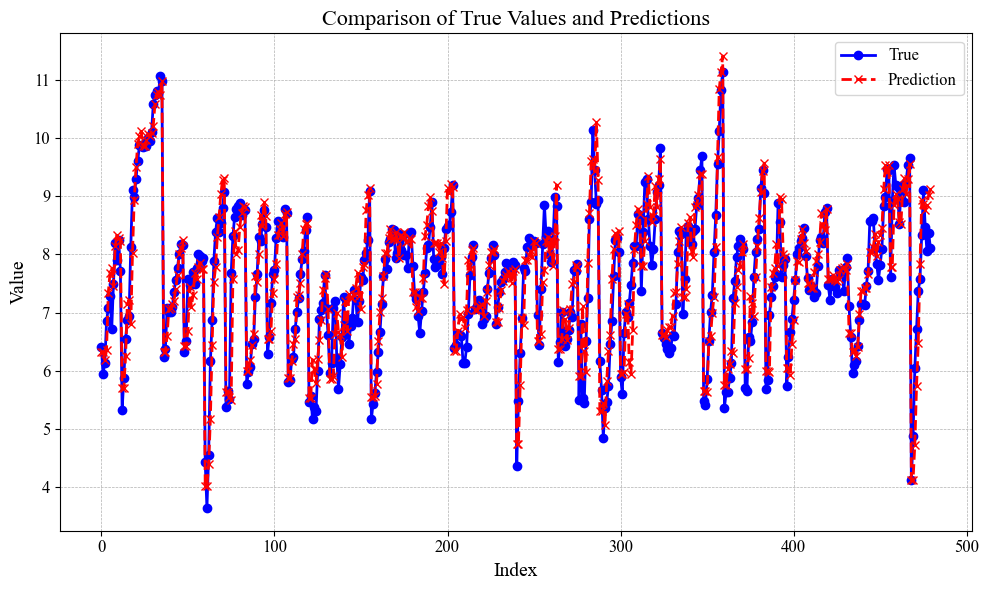

In [18]:
import matplotlib.pyplot as plt

# 假设 REALS 和 PREDS 是两个相同长度的列表或数组
# 如果它们还没有定义，请确保在调用 plot 之前定义它们

# 创建一个新的图形
plt.figure(figsize=(10, 6))  # 设置图形大小

# 绘制真实值
plt.plot(REALS, label='True', color='blue', marker='o', linestyle='-', linewidth=2)

# 绘制预测值
plt.plot(PREDS, label='Prediction', color='red', marker='x', linestyle='--', linewidth=2)

# 添加标题和坐标轴标签
plt.title('Comparison of True Values and Predictions', fontsize=16)
plt.xlabel('Index', fontsize=14)  # X 轴标签
plt.ylabel('Value', fontsize=14)  # Y 轴标签

# 显示图例
plt.legend(fontsize=12)

# 添加网格线
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 确保 x 轴和 y 轴的刻度标签足够大，以便阅读
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 自动调整布局以适应图形窗口
plt.tight_layout()
plt.savefig('plot.png',dpi=300)
# 显示图形
plt.show()

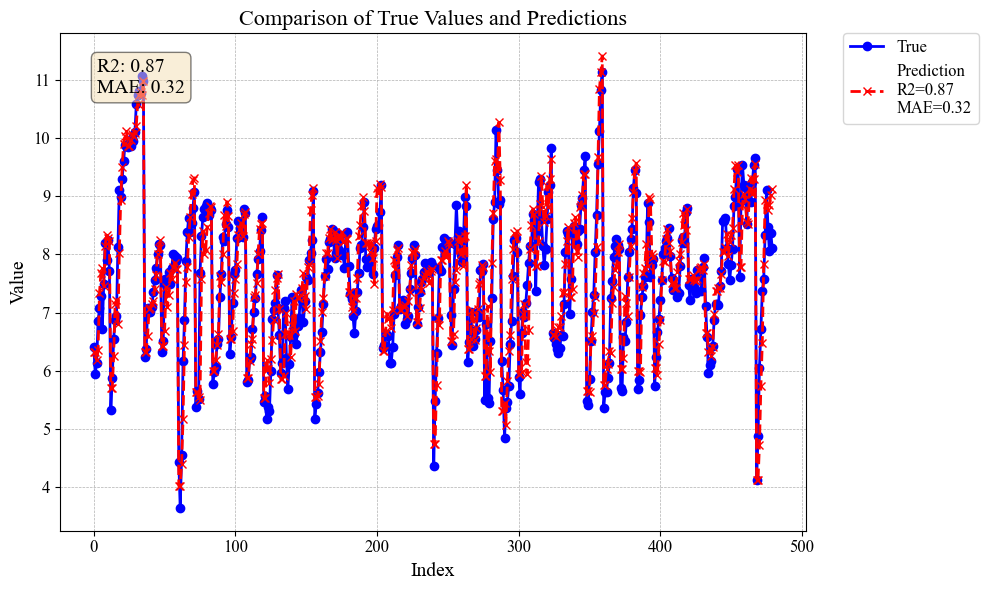

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# 假设 REALS 和 PREDS 是两个相同长度的列表或数组
# 如果它们还没有定义，请确保在调用 plot 之前定义它们

# 计算评估指标
r2 = r2_score(REALS, PREDS)
mae = mean_absolute_error(REALS, PREDS)

# 创建一个新的图形
plt.figure(figsize=(10, 6))  # 设置图形大小

# 绘制真实值
plt.plot(REALS, label='True', color='blue', marker='o', linestyle='-', linewidth=2)

# 绘制预测值
plt.plot(PREDS, label=f'Prediction\nR2={r2:.2f}\nMAE={mae:.2f}', 
         color='red', marker='x', linestyle='--', linewidth=2)

# 添加标题和坐标轴标签
plt.title('Comparison of True Values and Predictions', fontsize=16)
plt.xlabel('Index', fontsize=14)  # X 轴标签
plt.ylabel('Value', fontsize=14)  # Y 轴标签

# 显示图例
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0., fontsize=12)

# 添加网格线
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 确保 x 轴和 y 轴的刻度标签足够大，以便阅读
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 在图中添加R²和MAE的文本框
textstr = f'R2: {r2:.2f}\nMAE: {mae:.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=14,
         verticalalignment='top', bbox=props)

# 自动调整布局以适应图形窗口
plt.tight_layout()
plt.savefig('plot_r2_mae.png',dpi=300)
# 显示图形
plt.show()

c:\Users\Administrator\Desktop\数字经济\新\指标结果\补充\补充\GCN-Transformer\utils.py:81: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0,color='pink',marker='*')


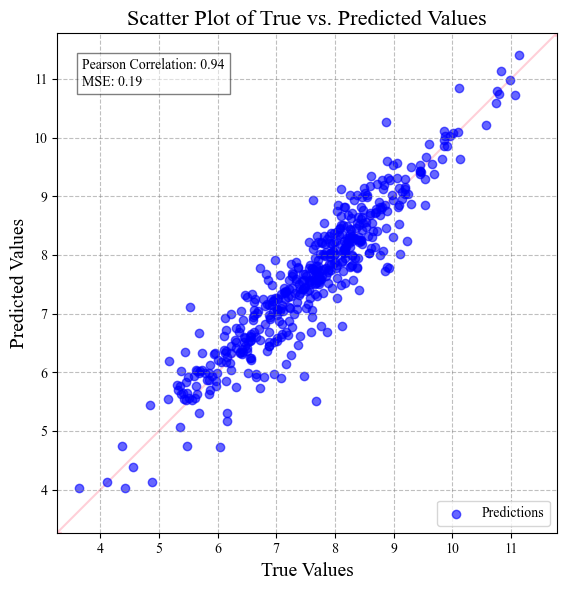

In [20]:
ErrorPlot(REALS, PREDS)

In [21]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

def ErrorPlot(true_values, predicted_values):
    # 计算相关系数和均方误差
    corr, _ = pearsonr(true_values, predicted_values)
    mse = mean_squared_error(true_values, predicted_values)
    # 设置字体
    plt.rcParams['font.family'] = 'Times New Roman'
    # 创建一个新的图形
    fig, ax = plt.subplots(figsize=(8, 8))
    # 绘制散点图
    ax.scatter(true_values, predicted_values, color='blue', alpha=0.6, label='Predictions',marker='o')
    # 绘制对角线
    lims = [np.min([ax.get_xlim(), ax.get_ylim()]),  # 设置对角线的起始位置
            np.max([ax.get_xlim(), ax.get_ylim()])]  # 设置对角线的结束位置
    ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0,color='pink',marker='*')
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # 添加标题和标签
    ax.set_title('GCN-Transformer Scatter Plot of True vs. Predicted Values', fontsize=16)
    ax.set_xlabel('True Values', fontsize=14)
    ax.set_ylabel('Predicted Values', fontsize=14)

    # 添加网格线
    ax.grid(True, which="both", ls="--", c='gray', alpha=0.5)

    # 添加统计信息
    stats_text = f'Pearson Correlation: {corr:.2f}\nMSE: {mse:.2f}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))

    # 添加图例
    ax.legend()

    # 调整布局
    plt.tight_layout()

    # 显示图形
    plt.show()

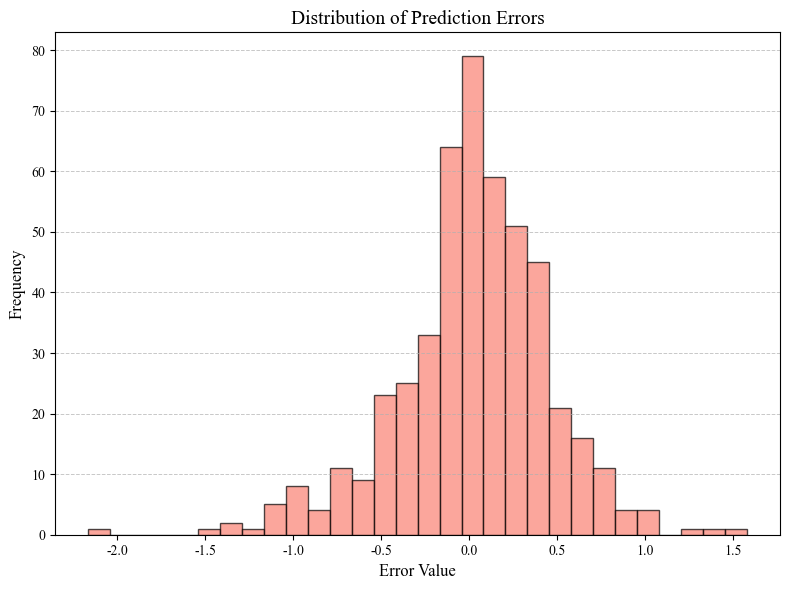

In [22]:
BinsrPlot(np.array(REALS),np.array(PREDS))